In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

print(jax.devices())

from src_renyi import (
    ARNN_Z2, RBM_Z2,
    FreeRenyiEnergyObservable,
    free_energy_minimize_SR_SGD,
    free_energy_minimize_scipy,
    renyi_entropy_maximize_SR_SGD,
    renyi2_entropy_and_grad_sampled,
    renyi2_entropy_and_grad_sampled2,
    renyi2_entropy_and_grad_lambda_integral,
    renyi2_entropy_and_grad_cv
)

[CudaDevice(id=0)]


In [19]:
# Hilbert space
from netket.hilbert import Spin
N = 4
N_ancilla = 4
partition = list(range(N))

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [20]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

Step    0 | F=-5.367013 | t=5.036s
Step   20 | F=-7.437159 | t=0.039s
Step   40 | F=-7.432738 | t=0.043s
Step   60 | F=-7.446140 | t=0.039s
Step   80 | F=-7.450923 | t=0.039s
Step  100 | F=-7.468453 | t=0.041s
Step  120 | F=-7.471267 | t=0.041s
Step  140 | F=-7.521503 | t=0.042s
Step  160 | F=-7.486588 | t=0.040s
Step  180 | F=-7.454918 | t=0.044s
Step  200 | F=-7.479613 | t=0.042s
Step  220 | F=-7.461572 | t=0.050s
Step  240 | F=-7.453551 | t=0.047s
Step  260 | F=-7.461661 | t=0.047s
Step  280 | F=-7.479101 | t=0.047s


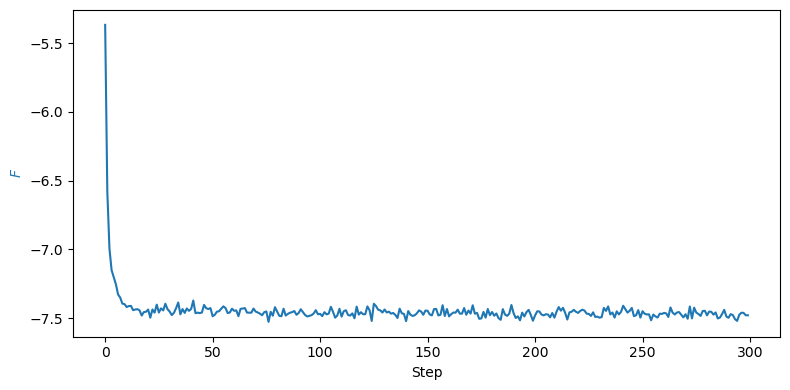

Best solution: S₂=0.874302, E=-5.878589, F=-7.452332


In [21]:
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960*1)
T = 1.8

n_steps = 300
lr = optax.linear_schedule(0.05, 0.001, n_steps)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)
_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr,
                                                      diag_shift=diag_shift, freq=20, timing=True, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

In [11]:
arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960/2)
lr = optax.linear_schedule(0.1, 0.05, n_steps)
_,_,_ = renyi_entropy_maximize_SR_SGD(vstate, partition, 300, 50, learning_rate=lr, diag_shift=diag_shift, timing=True)

Step    0 | S₂=2.413794 | t=0.406s
Step   50 | S₂=5.952082 | t=0.211s


KeyboardInterrupt: 

Temperaturas:   0%|          | 0/11 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | F=-5.976734
Step   50 | F=-6.759626
Step  100 | F=-6.760027
Step  150 | F=-6.759171
Step  200 | F=-6.759505
Step  250 | F=-6.759035


Temperaturas:   9%|▉         | 1/11 [00:17<02:52, 17.25s/it]

  Mejor resultado: E=-6.7601, S₂=-0.0000, F=-6.7601

=== Temperatura T = 0.500 ===
Step    0 | F=-6.759403
Step   50 | F=-6.758913
Step  100 | F=-6.759480
Step  150 | F=-6.759969
Step  200 | F=-6.759564
Step  250 | F=-6.759987


Temperaturas:  18%|█▊        | 2/11 [00:26<01:53, 12.66s/it]

...

  Mejor resultado: E=-2.0557, S₂=2.4547, F=-11.8746

=== Temperatura T = 4.500 ===
Step    0 | F=-13.141962
Step   50 | F=-13.013848
Step  100 | F=-13.319397
Step  150 | F=-13.040285
Step  200 | F=-13.261795
Step  250 | F=-13.085911


Temperaturas:  91%|█████████ | 10/11 [01:49<00:10, 10.42s/it]

  Mejor resultado: E=-1.6057, S₂=2.5921, F=-13.2699

=== Temperatura T = 5.000 ===
Step    0 | F=-14.515197
Step   50 | F=-13.354891
Step  100 | F=-14.535144
Step  150 | F=-14.643950
Step  200 | F=-14.750631
Step  250 | F=-14.588661


Temperaturas: 100%|██████████| 11/11 [01:59<00:00, 10.85s/it]

  Mejor resultado: E=-1.4273, S₂=2.6173, F=-14.5136


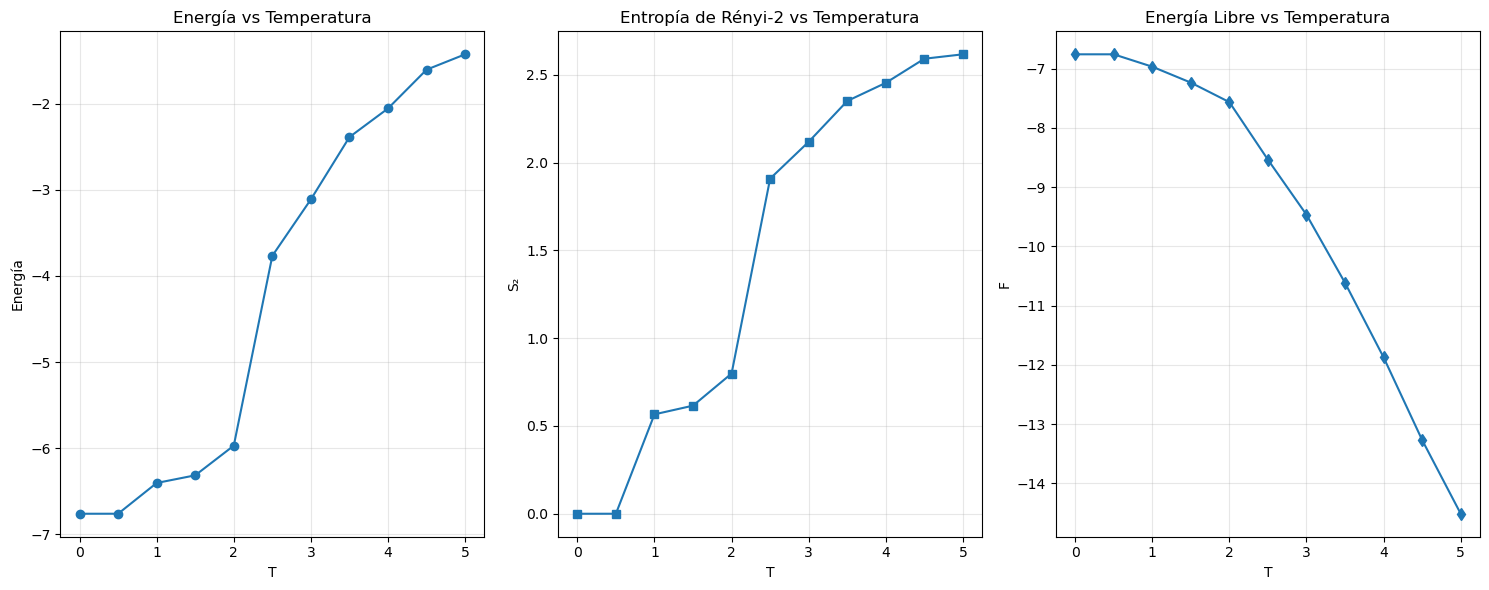

In [22]:
partition = list(range(N))
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960, chunk_size=None)

T_array = np.linspace(0, 5, 11)
n_steps = 300

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    if best_params is not None:
        vstate.parameters = best_params

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate = optax.linear_schedule(0.05, 0.001, n_steps),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
        n_samples_sr=4096
    )
    best_params = vstate.parameters

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
os.makedirs(f"../data/N{N}", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"../data/N{N}/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()